<a href="https://colab.research.google.com/github/Tahmidro/Deep-Learning-Notebooks-Learning-phase-/blob/main/hand_digit_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader,TensorDataset
import numpy as np


In [ ]:
TrainImages=np.load('/content/train_images.npy')
TrainLabels=np.load('/content/train_labels.npy')
TestImages=np.load('/content/test_images.npy')
TestLabels=np.load('/content/test_labels.npy')

In [ ]:
print(f"TrainImages shape: {TrainImages.shape}")
print(f"TrainLabels shape: {TrainLabels.shape}")
print(f"TestImages shape: {TestImages.shape}")
print(f"TestLabels shape: {TestLabels.shape}")

TrainImages shape: (60000, 28, 28)
TrainLabels shape: (60000,)
TestImages shape: (10000, 28, 28)
TestLabels shape: (10000,)


In [ ]:
TrainImages[9]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0, 189, 190,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0, 143, 247, 153,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0, 136, 247, 242,  86,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0, 192, 252, 187,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  62,
        185,  18,   0,   0,   0,   0,  89, 236, 217,  47,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 216,
        253,  60,   0,   0,   0,   0, 212, 255,  81,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 206,
        252,  68,   0,   0,   0,  48, 242, 253,  89,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 131, 251,
        212,  21,   0,   0,  11, 167, 252, 197,   5,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  29, 232, 247,
         63,   0,   0,   0, 153, 252, 226,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  45, 219, 252, 143,
          0,   0,   0, 116, 249, 252, 103,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   4,  96, 253, 255, 253, 200,
        122,   7,  25, 201, 250, 158,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  92, 252, 252, 253, 217, 252,
        252, 200, 227, 252, 231,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  87, 251, 247, 231,  65,  48, 189,
        252, 252, 253, 252, 251, 227,  35,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 190, 221,  98,   0,   0,   0,  42,
        196, 252, 253, 252, 252, 162,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 111,  29,   0,   0,   0,   0,  62,
        239, 252,  86,  42,  42,  14,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  15, 148,
        253, 218,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 121, 252,
        231,  28,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  31, 221, 251,
        129,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 218, 252, 160,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 122, 252,  82,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

In [ ]:
TrainLabels[9]

np.uint8(4)

seeing images with matplotlib


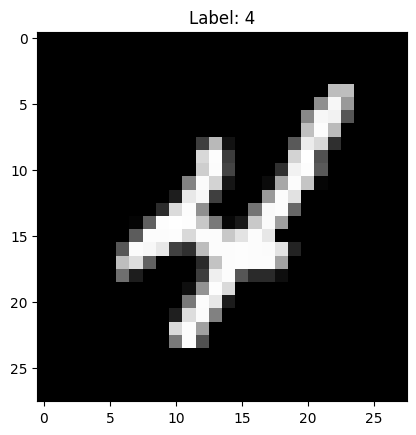

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(TrainImages[9],cmap="grey")
plt.title(f"Label: {TrainLabels[9]}")
plt.show()

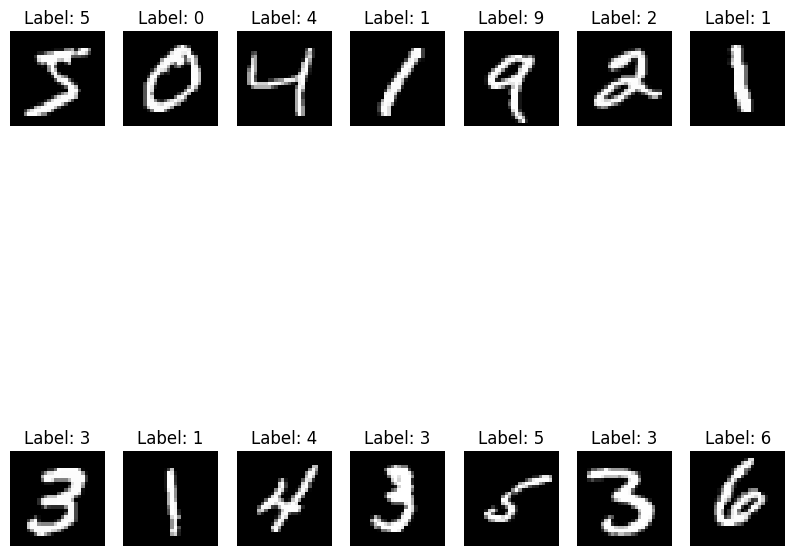

In [ ]:
fig,axes=plt.subplots(nrows=2,ncols=7,figsize=(10,10))
axes=axes.flatten()
for i in range(14):
  axes[i].imshow(TrainImages[i],cmap="grey")
  axes[i].set_title(f"Label: {TrainLabels[i]}")
  axes[i].axis("off")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_val,y_train,y_val=train_test_split(TrainImages,TrainLabels,test_size=0.1,random_state=42)


In [ ]:
X_train=torch.tensor(X_train,dtype=torch.float32)
y_train=torch.tensor(y_train,dtype=torch.long)
X_val=torch.tensor(X_val,dtype=torch.float32)
y_val=torch.tensor(y_val,dtype=torch.long)


In [ ]:
x_test=torch.tensor(TestImages,dtype=torch.float32)
y_test=torch.tensor(TestLabels,dtype=torch.long)
#

In [ ]:
TrainDataset=TensorDataset(X_train,y_train)
ValDataset=TensorDataset(X_val,y_val)
TestDataset=TensorDataset(x_test,y_test)

In [ ]:
trainLoader=DataLoader(TrainDataset,batch_size=64,shuffle=True)
valLoader=DataLoader(ValDataset,batch_size=64,shuffle=False)
testLoader=DataLoader(TestDataset,batch_size=64,shuffle=False)
#

In [ ]:
class digitClassificationModel(nn.Module):
  def __init__(self,inputSize,outputSize):
    super().__init__()
    self.network=nn.Sequential(
        nn.Flatten(),
        nn.Linear(inputSize,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,outputSize)
        )
  def forward(self,features):
    output=self.network(features)
    return output

In [ ]:
model=digitClassificationModel(28*28,10)
model

digitClassificationModel(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [ ]:
criterion=nn.CrossEntropyLoss()
optimizer=optim.SGD(model.parameters(),lr=0.01)

In [ ]:
epochs=13
for epoch in range(epochs):
  runningLoss=0
  for images,labels in trainLoader:
    optimizer.zero_grad()
    outputs=model(images)
    loss=criterion(outputs,labels)
    loss.backward()
    optimizer.step()
    runningLoss+=loss.item()
  valLoss=0
  with torch.no_grad():
    for images,labels in valLoader:
      outputs=model(images)
      loss=criterion(outputs,labels)
      valLoss+=loss.item()
  print(f"Epoch {epoch+1}/{epochs}, Training Loss: {runningLoss}, Validation Loss: {valLoss}")


Epoch 1/13, Training Loss: 2437.366861283779, Validation Loss: 116.28728032112122
Epoch 2/13, Training Loss: 897.1102302074432, Validation Loss: 75.86093655228615
Epoch 3/13, Training Loss: 629.2370481491089, Validation Loss: 59.315460085868835
Epoch 4/13, Training Loss: 490.07545337080956, Validation Loss: 57.379901736974716
Epoch 5/13, Training Loss: 446.05646808445454, Validation Loss: 47.23240438103676
Epoch 6/13, Training Loss: 430.50396560132504, Validation Loss: 48.56547752022743
Epoch 7/13, Training Loss: 424.3759583681822, Validation Loss: 44.402665346860886
Epoch 8/13, Training Loss: 419.8870416432619, Validation Loss: 44.63009387254715
Epoch 9/13, Training Loss: 420.5074290037155, Validation Loss: 45.576650351285934
Epoch 10/13, Training Loss: 431.295450925827, Validation Loss: 46.69121325016022
Epoch 11/13, Training Loss: 414.7464843094349, Validation Loss: 44.39796815812588
Epoch 12/13, Training Loss: 419.79282408952713, Validation Loss: 46.74084551632404
Epoch 13/13, Trai

In [ ]:
from sklearn.metrics import accuracy_score
with torch.no_grad():
  yPredProb=model(x_test)
  yPred=torch.argmax(yPredProb,dim=1)
accuracy_score(y_test,yPred)

AttributeError: module 'torch' has no attribute 'accuracy_score'